## 1. Importing Libraries & Loading Dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading dataset
df = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

df.columns = df.columns.str.strip()  #Removing extra space
print("Dataset Loaded Successfully\n")
print(f"Dataset Shape: {df.shape[0]} Rows, {df.shape[1]} Columns\n")
print("First 5 rows of the dataset")
display(df.head())

#checking null values
print("\n Null Values in Dataset")
print(df.isnull().sum())

Dataset Loaded Successfully

Dataset Shape: 267 Rows, 9 Columns

First 5 rows of the dataset


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74



 Null Values in Dataset
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


## 2. Data Cleaning & Type Conversion

In [9]:
# 1. Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Rename 'Region.1' to 'Zone' for better clarity
df.rename(columns={'Region.1': 'Zone'}, inplace=True)

# 3. Simplify column names to make coding easier
df.rename(columns={
        'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
        'Estimated Employed': 'Employed',
        'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}, inplace=True)

print("Data Types After Conversion")
print(df.dtypes)
print("\n Cleaned Dataset")
display(df.head())

Data Types After Conversion
Region                               object
Date                         datetime64[ns]
Frequency                            object
Unemployment_Rate                   float64
Employed                              int64
Labour_Participation_Rate           float64
Zone                                 object
longitude                           float64
latitude                            float64
dtype: object

 Cleaned Dataset


/tmp/ipykernel_7635/3464711252.py:2: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Zone,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


## 3. EDA: Top 10 States with the Highest Average Unemployment Rate

/tmp/ipykernel_7635/2341342118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Unemployment_Rate', data=avg_unemp.head(10), palette='viridis')


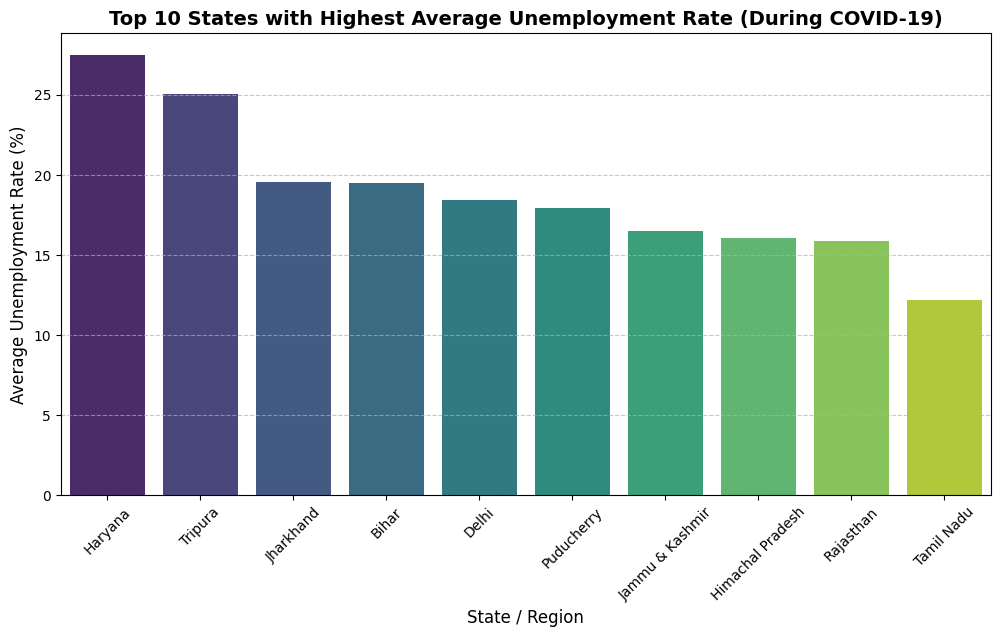


 Average Unemployment Rate (Top 10)


,Region,Unemployment_Rate
0,Haryana,27.477000
1,Tripura,25.055000
2,Jharkhand,19.539000
3,Bihar,19.471000
4,Delhi,18.414000
5,Puducherry,17.942000
6,Jammu & Kashmir,16.477778
7,Himachal Pradesh,16.065000
8,Rajasthan,15.868000
9,Tamil Nadu,12.187000


In [19]:
# Grouping the data by Region to find the average unemployment rate
avg_unemp = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).reset_index()

# Creating a Bar Chart for the Top 10 states
plt.figure(figsize=(12, 6))
sns.barplot(x='Region', y='Unemployment_Rate', data=avg_unemp.head(10), palette='viridis')

# Formatting the graph
plt.xticks(rotation=45)
plt.title('Top 10 States with Highest Average Unemployment Rate (During COVID-19)', fontsize=14, fontweight='bold')
plt.xlabel('State / Region', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

# Displaying the exact numbers below the graph
print("\n Average Unemployment Rate (Top 10)")
display(avg_unemp.head(10))

## 4. Time-Series Analysis: Unemployment Rate Over Time

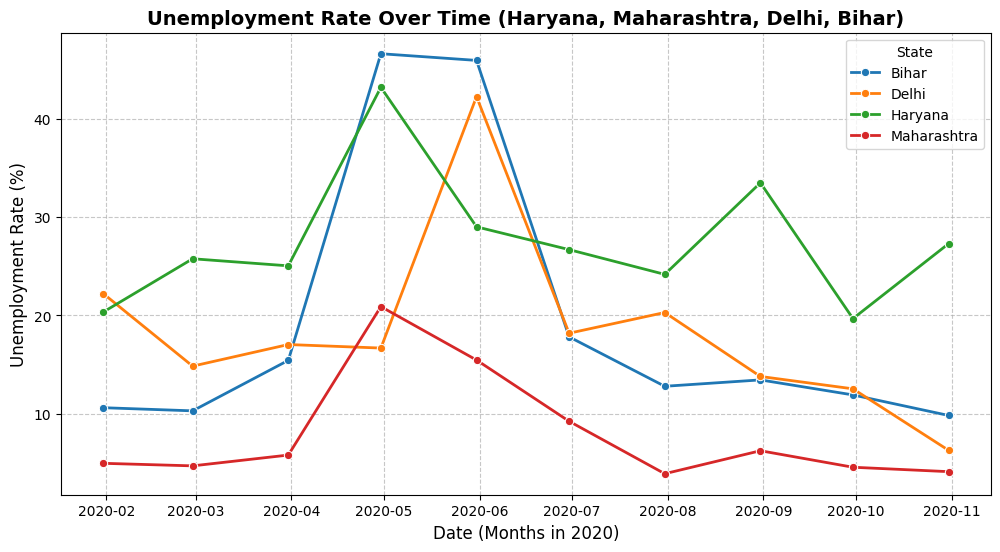

In [17]:
# Selecting 4 major states for comparison
states_to_plot = ['Haryana', 'Maharashtra', 'Delhi', 'Bihar']

# Filtering the dataset for only these 4 states
df_4_states = df[df['Region'].isin(states_to_plot)]

# Creating the Line Chart
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Unemployment_Rate', hue='Region', data=df_4_states, marker='o', linewidth=2)

# Formatting the graph
plt.title('Unemployment Rate Over Time (Haryana, Maharashtra, Delhi, Bihar)', fontsize=14, fontweight='bold')
plt.xlabel('Date (Months in 2020)', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='State')

# Display the plot
plt.show()

## 5. Correlation Heatmap

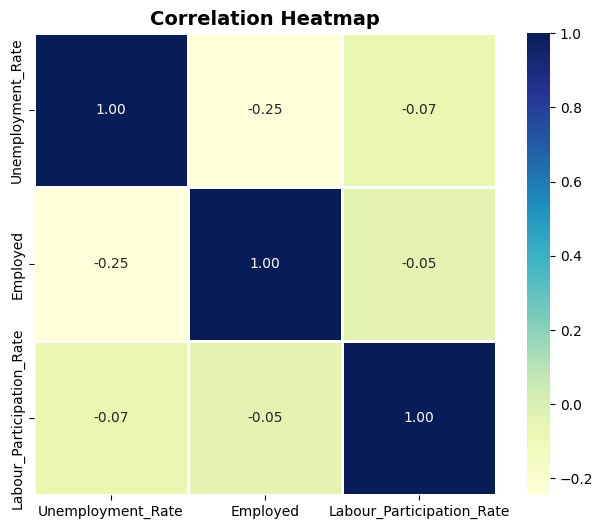

In [20]:
# Calculating the correlation matrix for numerical columns
correlation = df[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].corr()

# Creating the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=1, square=True)

# Formatting the graph
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')

# Display the plot
plt.show()

## 6. Impact of COVID-19: Pre-COVID vs. During COVID-19

--- National Average Unemployment Rate ---
Pre-COVID (Jan-Mar 2020): 9.76%
During COVID (Apr-Nov 2020): 13.28%



/tmp/ipykernel_7635/1947036811.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Pre-COVID (Jan-Mar 2020)', 'During COVID (Apr-Nov 2020)'],


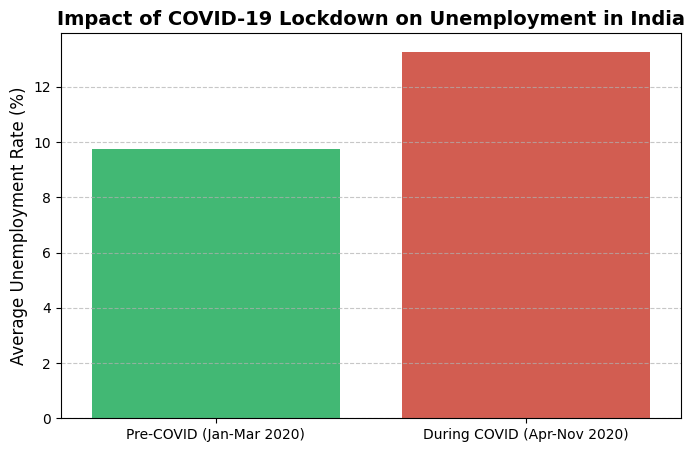

In [21]:
# Lockdown started in late March 2020, so we split data before and after April 1st
pre_covid = df[df['Date'] < '2020-04-01']
during_covid = df[df['Date'] >= '2020-04-01']

# Calculating the mean unemployment rates for both periods
mean_pre = pre_covid['Unemployment_Rate'].mean()
mean_during = during_covid['Unemployment_Rate'].mean()

# Printing the exact numbers
print("--- National Average Unemployment Rate ---")
print(f"Pre-COVID (Jan-Mar 2020): {mean_pre:.2f}%")
print(f"During COVID (Apr-Nov 2020): {mean_during:.2f}%\n")

# Visualizing the impact with a Bar Chart
plt.figure(figsize=(8, 5))
# Green color for Pre-COVID and Red for During COVID
sns.barplot(x=['Pre-COVID (Jan-Mar 2020)', 'During COVID (Apr-Nov 2020)'],
            y=[mean_pre, mean_during],
            palette=['#2ecc71', '#e74c3c'])

plt.title('Impact of COVID-19 Lockdown on Unemployment in India', fontsize=14, fontweight='bold')
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

## 8. Final Conclusion & Observations

Based on the Exploratory Data Analysis (EDA) of the Unemployment dataset during the COVID-19 period, we can conclude the following:

1. **State-Level Impact:** Haryana and Tripura experienced the most severe average unemployment rates during this period, indicating high vulnerability in their regional job markets.
2. **The Lockdown Spike:** The time-series analysis clearly shows a massive spike in the unemployment rate around **April and May 2020**. This directly aligns with the strict nationwide lockdown imposed in India, which abruptly halted industrial and economic activities.
3. **Pre vs. Post-COVID Comparison:** There is a drastic and visible difference in the national average unemployment rate before the lockdown (Jan-Mar 2020) compared to during the lockdown (Apr-Nov 2020).
4. **Correlation:** As expected, there is a strong negative correlation between the Employment Rate and the Unemployment Rate. When employment numbers dropped drastically during the lockdown, unemployment numbers skyrocketed.

*Overall, this analysis visualizes the devastating short-term impact of the COVID-19 pandemic on the Indian workforce and economy.*